In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [81]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [82]:
Exploded_Job_skills = df_DA.explode('job_skills')

In [83]:
The_highest_skills = Exploded_Job_skills.groupby(['job_title_short', 'job_skills']).size().reset_index(name='Skill Count').sort_values(by='Skill Count', ascending=False )

In [84]:
The_highest_skills

,job_title_short,job_skills,Skill Count
189,Data Analyst,sql,92428
58,Data Analyst,excel,66860
154,Data Analyst,python,57190
202,Data Analyst,tableau,46455
147,Data Analyst,power bi,39380
...,...,...,...
23,Data Analyst,capacitor,1
131,Data Analyst,nuxt.js,1
117,Data Analyst,msaccess,1
137,Data Analyst,ovh,1


In [85]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month



In [86]:
df_DA_Exploaded = df_DA.explode('job_skills')
Pivot_Arrangement = df_DA_Exploaded.pivot_table(index= 'job_posted_month_no', columns= 'job_skills', aggfunc='size', fill_value=0)



In [87]:
Pivot_Arrangement

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [88]:
Pivot_Arrangement = Pivot_Arrangement.reset_index()
Pivot_Arrangement['job_posted_month'] = Pivot_Arrangement['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
Pivot_Arrangement = Pivot_Arrangement.set_index('job_posted_month')
Pivot_Arrangement = Pivot_Arrangement.drop(columns='job_posted_month_no')


In [89]:
Pivot_Arrangement.loc['Total'] = Pivot_Arrangement.sum()

Sorted_Pivot = Pivot_Arrangement[Pivot_Arrangement.loc['Total'].sort_values(ascending=False).index]
Removed_Total = Sorted_Pivot.drop('Total')
Removed_Total.iloc[:, :5]

job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
Jan,11336,8170,6606,5596,4285
Feb,7947,5772,4751,3936,3307
Mar,7868,5675,4741,4051,3176
Apr,7553,5496,4557,3776,3106
May,6617,4773,4070,3245,2695
Jun,7584,5724,4707,3812,3275
Jul,7687,5513,4831,3928,3350
Aug,8823,6482,5576,4533,3859
Sep,6829,4886,4229,3446,3118


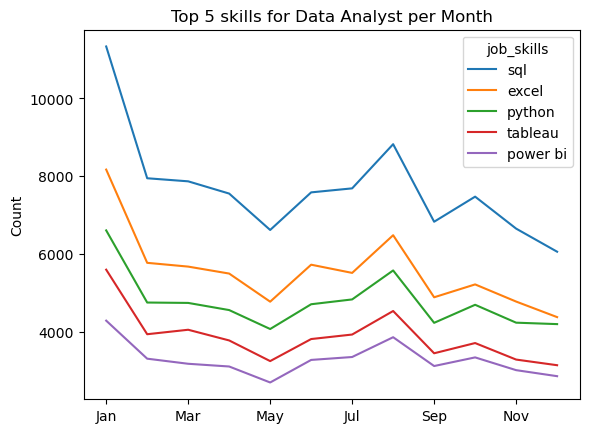

In [90]:
Removed_Total.iloc[:, :5].plot(kind='line')


plt.title('Top 5 skills for Data Analyst per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()